Connect to dataset on google drive if you want to run notebook on google colab

In [1]:
# Load the Drive helper and mount
from google.colab import drive

# This will prompt for authorization.
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#import all required libraries and constants
import os
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Define paths and parameters
NUM_CLASSES = 2  # Number of classes (bonafide and spoof)
SAMPLE_RATE = 22050  # Sample rate of your audio files
DURATION = 5  # Duration of audio clips in seconds
max_time_steps = 109  # Define the maximum time steps for your model
N_MFCC = 13  # You can adjust this value based on your needs


This code snippet performs the extraction and preprocessing of audio data for a deepfake detection model using Mel-frequency cepstral coefficients (MFCC). The process involves loading audio files from both real and fake data stored in 4 separate directories as :

RARV represent real audio real video

RAFV represent real audio fake video

FARV represent fake audio real video

FAFV represent fake audio fake video

then both RARV and RAFV contain real audio,

and both FARV and FAFV contain fake audio.

 The audio data is loaded using the Librosa library, and a custom function, extract_mfcc, is utilized to obtain MFCC features. The extracted features are then standardized to have consistent dimensions in terms of the number of time steps. Real and fake audio samples are distinguished through corresponding labels (1 for real and 0 for fake). The resulting MFCC features, along with their respective labels, are appended to arrays (X and Y). The overall process ensures that the audio data is appropriately prepared for subsequent use in training a deepfake detection model.

In [4]:
import os
import librosa
import numpy as np

# Function to extract MFCC features
def extract_mfcc(audio, sample_rate, n_mfcc=13):
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    return mfccs

# Directory paths
real_audio_dir = '/content/drive/MyDrive/RARV_audio'
real_audio_dir_2 = '/content/drive/MyDrive/RAFV_audio'
fake_audio_dir = '/content/drive/MyDrive/FARV_audio'
fake_audio_dir_2 = '/content/drive/MyDrive/FAFV_audio'

# Lists to store features and labels
X = []
Y = []

# Load and preprocess real audio data
for file in os.listdir(real_audio_dir):
    if file.endswith('.flac'):
        audio_path = os.path.join(real_audio_dir, file)
        try:
            # Load audio file using librosa
            audio, _ = librosa.load(audio_path, sr=SAMPLE_RATE, duration=DURATION)

            # Extract MFCC features using custom function
            mfcc_features = extract_mfcc(audio, SAMPLE_RATE, n_mfcc=N_MFCC)

            # Ensure all MFCC features have the same width (time steps)
            if mfcc_features.shape[1] < max_time_steps:
                mfcc_features = np.pad(mfcc_features, ((0, 0), (0, max_time_steps - mfcc_features.shape[1])), mode='constant')
            else:
                mfcc_features = mfcc_features[:, :max_time_steps]

            X.append(mfcc_features)
            Y.append(1)
        except FileNotFoundError:
            print(f"File not found: {file}")

# Load and preprocess real audio data (second directory)
for file in os.listdir(real_audio_dir_2):
    if file.endswith('.flac'):
        audio_path = os.path.join(real_audio_dir_2, file)
        try:
            # Load audio file using librosa
            audio, _ = librosa.load(audio_path, sr=SAMPLE_RATE, duration=DURATION)

            # Extract MFCC features using custom function
            mfcc_features = extract_mfcc(audio, SAMPLE_RATE, n_mfcc=N_MFCC)

            # Ensure all MFCC features have the same width (time steps)
            if mfcc_features.shape[1] < max_time_steps:
                mfcc_features = np.pad(mfcc_features, ((0, 0), (0, max_time_steps - mfcc_features.shape[1])), mode='constant')
            else:
                mfcc_features = mfcc_features[:, :max_time_steps]

            X.append(mfcc_features)
            Y.append(1)
        except FileNotFoundError:
            print(f"File not found: {file}")

# Load and preprocess fake audio data
for file in os.listdir(fake_audio_dir):
    if file.endswith('.flac'):
        audio_path = os.path.join(fake_audio_dir, file)
        try:
            # Load audio file using librosa
            audio, _ = librosa.load(audio_path, sr=SAMPLE_RATE, duration=DURATION)

            # Extract MFCC features using custom function
            mfcc_features = extract_mfcc(audio, SAMPLE_RATE, n_mfcc=N_MFCC)

            # Ensure all MFCC features have the same width (time steps)
            if mfcc_features.shape[1] < max_time_steps:
                mfcc_features = np.pad(mfcc_features, ((0, 0), (0, max_time_steps - mfcc_features.shape[1])), mode='constant')
            else:
                mfcc_features = mfcc_features[:, :max_time_steps]

            X.append(mfcc_features)
            Y.append(0)
        except FileNotFoundError:
            print(f"File not found: {file}")

# Load and preprocess fake audio data (second directory)
for file in os.listdir(fake_audio_dir_2):
    if file.endswith('.flac'):
        audio_path = os.path.join(fake_audio_dir_2, file)
        try:
            # Load audio file using librosa
            audio, _ = librosa.load(audio_path, sr=SAMPLE_RATE, duration=DURATION)

            # Extract MFCC features using custom function
            mfcc_features = extract_mfcc(audio, SAMPLE_RATE, n_mfcc=N_MFCC)

            # Ensure all MFCC features have the same width (time steps)
            if mfcc_features.shape[1] < max_time_steps:
                mfcc_features = np.pad(mfcc_features, ((0, 0), (0, max_time_steps - mfcc_features.shape[1])), mode='constant')
            else:
                mfcc_features = mfcc_features[:, :max_time_steps]

            X.append(mfcc_features)
            Y.append(0)
        except FileNotFoundError:
            print(f"File not found: {file}")

# Convert lists to numpy arrays
X = np.array(X)
Y = np.array(Y)


In [ ]:
# Save the arrays
np.save('/content/drive/MyDrive/X_mfcc.npy', X)
np.save('/content/drive/MyDrive/Y_mfcc.npy', Y)
# print(len(Y))

In [3]:
import numpy as np
# Load the arrays
X = np.load('/content/drive/MyDrive/X_mfcc.npy')
Y = np.load('/content/drive/MyDrive/Y_mfcc.npy')


In [4]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42,stratify=Y)

The next cell begins by defining the input shape based on the number of MFCC features. Afterthat, the CNN model is constructed with convolutional and pooling layers, followed by fully connected layers with dropout for regularization. The output layer has a sigmoid activation function, indicating binary classification. To adapt to the MFCC input, reshape and permute layers are added. Additionally, a learning rate scheduler is defined, and the model is compiled using the Adam optimizer with a binary crossentropy loss function and accuracy metric.

In [5]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Reshape, Permute
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler
import tensorflow.keras.backend as K

# Assuming input_shape is defined correctly
input_shape = (N_MFCC, X_train.shape[2], 1)

# Define CNN model architecture for MFCC input
model_input = Input(shape=input_shape)
x = Conv2D(64, kernel_size=(3, 3), activation='relu')(model_input)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Conv2D(32, kernel_size=(3, 3), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
model_output = Dense(1, activation='sigmoid')(x)

# Reshape layer to adapt to MFCC input shape
reshape_layer = Reshape((N_MFCC, X_train.shape[2]))(model_input)
permute_layer = Permute((2, 1))(reshape_layer)

# Function to schedule the learning rate
def lr_schedule(epoch):
    initial_lr = 0.0001  # Set your initial learning rate here
    decay_factor = 0.9  # Set the decay factor

    lr = initial_lr * decay_factor ** epoch
    return lr
# Create the learning rate scheduler callback
lr_scheduler = LearningRateScheduler(lr_schedule)

# Create and compile the model
model = Model(inputs=model_input, outputs=model_output)
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])


In [6]:
# Train the Model
history = model.fit(X_train, y_train, batch_size=32, epochs=10, validation_data=(X_val, y_val), callbacks=[lr_scheduler])

Epoch 1/10
432/432 [==============================] - 9s 8ms/step - loss: 1.0603 - accuracy: 0.7361 - val_loss: 0.1379 - val_accuracy: 0.9632 - lr: 1.0000e-04
Epoch 2/10
432/432 [==============================] - 2s 5ms/step - loss: 0.1733 - accuracy: 0.9336 - val_loss: 0.0467 - val_accuracy: 0.9849 - lr: 9.0000e-05
Epoch 3/10
432/432 [==============================] - 2s 5ms/step - loss: 0.0785 - accuracy: 0.9719 - val_loss: 0.0218 - val_accuracy: 0.9936 - lr: 8.1000e-05
Epoch 4/10
432/432 [==============================] - 2s 5ms/step - loss: 0.0418 - accuracy: 0.9855 - val_loss: 0.0136 - val_accuracy: 0.9962 - lr: 7.2900e-05
Epoch 5/10
432/432 [==============================] - 2s 5ms/step - loss: 0.0247 - accuracy: 0.9925 - val_loss: 0.0081 - val_accuracy: 0.9983 - lr: 6.5610e-05
Epoch 6/10
432/432 [==============================] - 2s 5ms/step - loss: 0.0216 - accuracy: 0.9931 - val_loss: 0.0080 - val_accuracy: 0.9983 - lr: 5.9049e-05
Epoch 7/10
432/432 [==========================

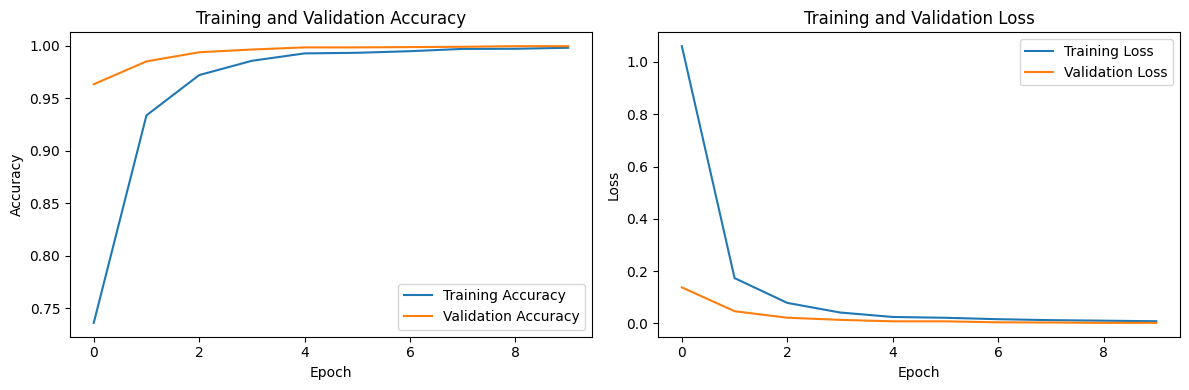

In [7]:

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))

# Plot training accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Plot training loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()

In [ ]:
# Save the entire model to a file after training
model.save("/content/drive/MyDrive/mfcc_audio_model.h5")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


The same prerocessing steps are applied on audio data within the test set

In [ ]:
import os
import librosa
import numpy as np

# Function to extract MFCC features
def extract_mfcc(audio, sample_rate, n_mfcc=13):
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    return mfccs

# Directory paths
real_audio_dir = '/content/drive/MyDrive/RARV_audio_test'
real_audio_dir_2 = '/content/drive/MyDrive/RAFV_audio_test'
fake_audio_dir = '/content/drive/MyDrive/FARV_audio_test'
fake_audio_dir_2 = '/content/drive/MyDrive/FAFV_audio_test'

# Lists to store features and labels
X_test= []
Y_test= []

# Load and preprocess real audio data
for file in os.listdir(real_audio_dir):
    if file.endswith('.flac'):
        audio_path = os.path.join(real_audio_dir, file)
        try:
            # Load audio file using librosa
            audio, _ = librosa.load(audio_path, sr=SAMPLE_RATE, duration=DURATION)

            # Extract MFCC features using custom function
            mfcc_features = extract_mfcc(audio, SAMPLE_RATE, n_mfcc=N_MFCC)

            # Ensure all MFCC features have the same width (time steps)
            if mfcc_features.shape[1] < max_time_steps:
                mfcc_features = np.pad(mfcc_features, ((0, 0), (0, max_time_steps - mfcc_features.shape[1])), mode='constant')
            else:
                mfcc_features = mfcc_features[:, :max_time_steps]

            X_test.append(mfcc_features)
            Y_test.append(1)
        except FileNotFoundError:
            print(f"File not found: {file}")

# Load and preprocess real audio data (second directory)
for file in os.listdir(real_audio_dir_2):
    if file.endswith('.flac'):
        audio_path = os.path.join(real_audio_dir_2, file)
        try:
            # Load audio file using librosa
            audio, _ = librosa.load(audio_path, sr=SAMPLE_RATE, duration=DURATION)

            # Extract MFCC features using custom function
            mfcc_features = extract_mfcc(audio, SAMPLE_RATE, n_mfcc=N_MFCC)

            # Ensure all MFCC features have the same width (time steps)
            if mfcc_features.shape[1] < max_time_steps:
                mfcc_features = np.pad(mfcc_features, ((0, 0), (0, max_time_steps - mfcc_features.shape[1])), mode='constant')
            else:
                mfcc_features = mfcc_features[:, :max_time_steps]

            X_test.append(mfcc_features)
            Y_test.append(1)
        except FileNotFoundError:
            print(f"File not found: {file}")

# Load and preprocess fake audio data
for file in os.listdir(fake_audio_dir):
    if file.endswith('.flac'):
        audio_path = os.path.join(fake_audio_dir, file)
        try:
            # Load audio file using librosa
            audio, _ = librosa.load(audio_path, sr=SAMPLE_RATE, duration=DURATION)

            # Extract MFCC features using custom function
            mfcc_features = extract_mfcc(audio, SAMPLE_RATE, n_mfcc=N_MFCC)

            # Ensure all MFCC features have the same width (time steps)
            if mfcc_features.shape[1] < max_time_steps:
                mfcc_features = np.pad(mfcc_features, ((0, 0), (0, max_time_steps - mfcc_features.shape[1])), mode='constant')
            else:
                mfcc_features = mfcc_features[:, :max_time_steps]

            X_test.append(mfcc_features)
            Y_test.append(0)
        except FileNotFoundError:
            print(f"File not found: {file}")

# Load and preprocess fake audio data (second directory)
for file in os.listdir(fake_audio_dir_2):
    if file.endswith('.flac'):
        audio_path = os.path.join(fake_audio_dir_2, file)
        try:
            # Load audio file using librosa
            audio, _ = librosa.load(audio_path, sr=SAMPLE_RATE, duration=DURATION)

            # Extract MFCC features using custom function
            mfcc_features = extract_mfcc(audio, SAMPLE_RATE, n_mfcc=N_MFCC)

            # Ensure all MFCC features have the same width (time steps)
            if mfcc_features.shape[1] < max_time_steps:
                mfcc_features = np.pad(mfcc_features, ((0, 0), (0, max_time_steps - mfcc_features.shape[1])), mode='constant')
            else:
                mfcc_features = mfcc_features[:, :max_time_steps]

            X_test.append(mfcc_features)
            Y_test.append(0)
        except FileNotFoundError:
            print(f"File not found: {file}")

# Convert lists to numpy arrays
X_test= np.array(X_test)
Y_test= np.array(Y_test)


In [ ]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, Y_test)
print(f'Test accuracy: {test_acc}')

540/540 [==============================] - 2s 4ms/step - loss: 2.0347e-04 - accuracy: 0.9999
Test accuracy: 0.9998841285705566


In [ ]:
# Evaluate the model on the test set
Y_pred = model.predict(X_test)


540/540 [==============================] - 1s 2ms/step
Test Preditions: [[1.0000000e+00]
 [1.0000000e+00]
 [1.0000000e+00]
 ...
 [1.2519317e-11]
 [1.0181366e-09]
 [4.9206899e-11]]


In [ ]:
import seaborn as sns

# Apply a threshold to convert probabilities into binary predictions
threshold = 0.5
y_pred = (Y_pred > threshold).astype(int)


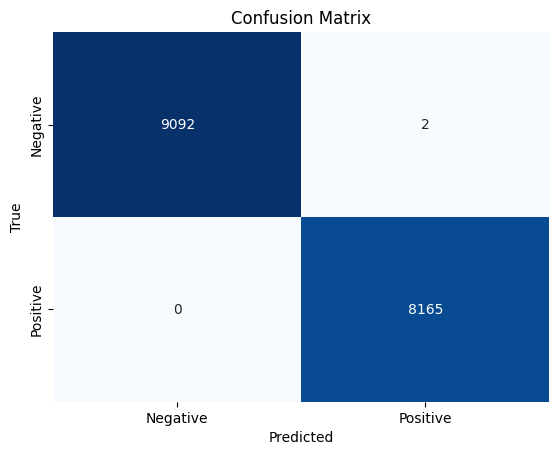

In [ ]:

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
# Create the confusion matrix
conf_matrix = confusion_matrix(Y_test, y_pred)

# Plot the confusion matrix using seaborn
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

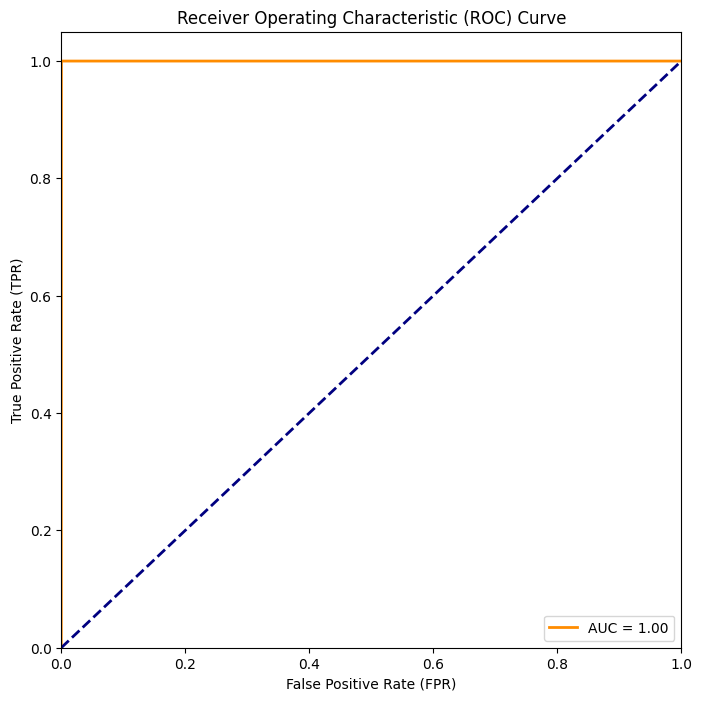

In [ ]:
from sklearn.metrics import roc_curve, auc
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(Y_test, y_pred)

# Compute area under the curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Assuming y_true contains the true labels and y_pred contains the predicted labels

# Calculate precision, recall, and F1-score
precision = precision_score(Y_test, y_pred)
recall = recall_score(Y_test, y_pred)
f1 = f1_score(Y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


Precision: 0.9997551120362435
Recall: 1.0
F1-score: 0.9998775410237571
